# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

 **Student 1 Name+ID

 **Student 2 Name+ID

<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
# from IPython.display import set_matplotlib_formats
# %config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [2]:
class ContinuousRepresentation(object):
    def __call__(self, tensor):
        # ToTensor scales to [0,1]. Revert to [0,255], add noise, scale to [0,1]
        tensor = tensor * 255.0 
        noise = torch.rand_like(tensor) # Uniform noise in [0,1]
        tensor = (tensor + noise) / 256.0
        return tensor

transform = transforms.Compose([
    transforms.ToTensor(),
    ContinuousRepresentation()
])

In [3]:
# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


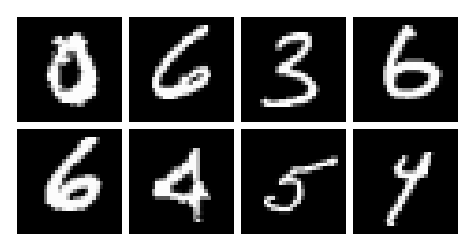

In [4]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

In [5]:
class VAE(nn.Module):

    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.logs = defaultdict(list)

        # ENCODER
        # Input: (1, 28, 28)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # -> (16, 14, 14)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> (32, 7, 7)
            nn.ReLU()
        )
        self.encoder_fc = nn.Sequential(
            nn.Linear(32 * 7 * 7, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_std = nn.Linear(256, latent_dim)
        
        # DECODER 
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 32 * 7 * 7),
            nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (16, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (1, 28, 28)
            nn.Sigmoid() # Restrict output to [0, 1] range
        )

    def log(self, key, value):
        self.logs[key].append(value)

    
    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.encoder_fc(x)
        mu = self.fc_mu(x)
        log_std = self.fc_log_std(x)
        return mu, log_std

    def decode(self, z):
        z = self.decoder_fc(z)
        z = z.view(z.size(0), 32, 7, 7) # Unflatten
        x_hat = self.decoder_conv(z)
        return x_hat

    def calc_elbo(self, x):
        # 1. Encode to get posterior parameters
        mu, log_std = self.encode(x)
        
        # 2. Reparameterization Trick (using PyTorch distributions rsample)
        std = torch.exp(log_std)
        q_z_x = torch.distributions.Normal(mu, std)
        z = q_z_x.rsample()
        
        # 3. Decode to get reconstruction means
        x_hat = self.decode(z)
        
        # 4. Reconstruction Log Likelihood simplified to Mean Squared Error 
        # based on constant variance var = 0.1^2
        var_c = 0.1 ** 2
        # Sum over channels, height, width. Mean over batch.
        rec_loss = (1.0 / (2.0 * var_c)) * torch.sum((x_hat - x)**2, dim=(1, 2, 3))
        rec_loss = rec_loss.mean()
        
        # 5. KL Divergence D_KL( q(z|x) || p(z) )
        p_z = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(std))
        KLD = torch.distributions.kl_divergence(q_z_x, p_z).sum(dim=1).mean()
        
        # 6. Negative ELBO (we minimize this loss)
        loss = rec_loss + KLD
        return loss, rec_loss, KLD
    
    @torch.no_grad()
    def sample(self, num_samples):
        # Sample from the standard isotropic Gaussian prior p(z)
        z = torch.randn(num_samples, self.latent_dim).to(device)
        # Pass through the decoder to get the means of p(x|z)
        samples = self.decode(z)
        return samples

    def training_step(self, batch):
        loss, rec_loss, KLD = self.calc_elbo(batch)
        self.log('train_elbo', loss.item())
        self.log('train_recon', rec_loss.item())
        self.log('train_KLD', KLD.item())
        return loss

    @torch.no_grad()
    def validation_step(self, loader):
        loss_obj = []
        for imgs, _ in loader:
          imgs = imgs.to(device)
          loss_obj.append(self.calc_elbo(imgs))
        
        loss_obj = torch.stack([torch.stack(x) for x in loss_obj])
        loss, rec_loss, KLD = loss_obj.mean(dim=0)

        # Log losses
        self.log('val_elbo', loss.item())
        self.log('val_recon', rec_loss.item())
        self.log('val_KLD', KLD.item())
        return loss

    @torch.no_grad()
    def test_step(self, loader):
        loss_obj = []
        for imgs, _ in loader:
          imgs = imgs.to(device)
          loss_obj.append(self.calc_elbo(imgs))

        loss_obj = torch.stack([torch.stack(x) for x in loss_obj])
        loss, rec_loss, KLD = loss_obj.mean(dim=0)
        # Log losses
        self.log('test_elbo', loss.item())
        self.log('test_recon', rec_loss.item())
        self.log('test_KLD', KLD.item())

        return loss

## Model Training

In [6]:
latent_dims = 50
model = VAE(latent_dim=latent_dims).to(device)
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=4e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
epochs = 50

Num params: 852,965


In [7]:
# Training loop
for epoch in range(epochs):
    model.train()
    losses = []
    print(f"Epoch {epoch+1}/{epochs}")

    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.training_step(imgs)
        loss.backward()
        optimizer.step()

    scheduler.step()
    val_loss = model.validation_step(val_loader)

    losses.append(val_loss)

# Test loop
model.eval()
final_loss = model.test_step(test_loader)
print(f"Final ELBO: {final_loss}")

# Save the model
torch.save(model.state_dict(), 'vae_model.pth')

Epoch 1/50
Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50
Final ELBO: 283.71826171875


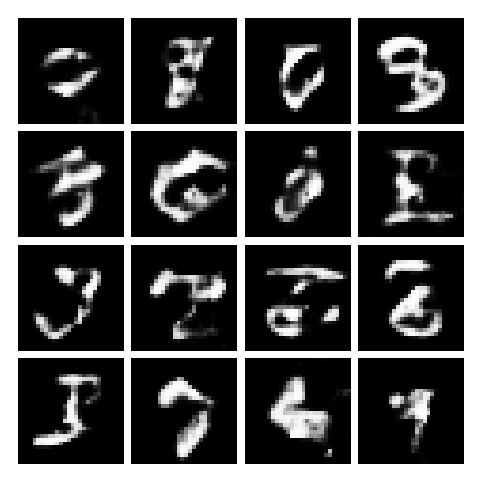

In [8]:
sampled_images = model.sample(num_samples=16)
show_imgs(sampled_images)